# Spatial deconvolution without reference scRNA-seq

This is a tutorial on an example real Spatial Transcriptomics (ST) data (CID44971_TNBC) from Wu et al., 2021. Raw tutorial could be found in https://starfysh.readthedocs.io/en/latest/notebooks/Starfysh_tutorial_real.html


Starfysh performs cell-type deconvolution followed by various downstream analyses to discover spatial interactions in tumor microenvironment. Specifically, Starfysh looks for anchor spots (presumably with the highest compositions of one given cell type) informed by user-provided gene signatures ([see example](https://drive.google.com/file/d/1AXWQy_mwzFEKNjAdrJjXuegB3onxJoOM/view?usp=share_link)) as priors to guide the deconvolution inference, which further enables downstream analyses such as sample integration, spatial hub characterization, cell-cell interactions, etc. This tutorial focuses on the deconvolution task. Overall, Starfysh provides the following options:

At omicverse, we have made the following improvements:
- Easier visualization, you can use omicverse unified visualization for scientific mapping
- Reduce installation dependency errors, we optimized the automatic selection of different packages, you don't need to install too many extra packages and cause conflicts.

**Base feature**:

- Spot-level deconvolution with expected cell types and corresponding annotated signature gene sets (default)


He, S., Jin, Y., Nazaret, A. et al.
Starfysh integrates spatial transcriptomic and histologic data to reveal heterogeneous tumor–immune hubs.
Nat Biotechnol (2024).
https://doi.org/10.1038/s41587-024-02173-8

In [1]:
import scanpy as sc
import omicverse as ov
ov.style(font_path='Arial')

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
Using already downloaded Arial font from: /tmp/omicverse_arial.ttf
Registered as: Arial
🧬 Detecting GPU devices…


✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.2rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## Step 1: Prepare spatial transcriptomics (1 min)

Purpose: load 10x Visium (Space Ranger outputs) or similar to obtain a coordinate-aware spatial `AnnData` (`adata_sp`).

- Inputs: Visium count matrix and spatial coordinates (from the `spatial` folder)
- Outputs: `AnnData` object (`adata_sp`) with spot coordinates and counts
- Key points:
  - Ensure maximal gene overlap with the scRNA-seq reference; map gene IDs if necessary.
  - For multiple samples, keep batch labels explicit to support merging and visualization.



In [2]:
adata_sp = sc.datasets.visium_sge(sample_id="V1_Human_Lymph_Node")
adata_sp.obs['sample'] = list(adata_sp.uns['spatial'].keys())[0]
adata_sp.var_names_make_unique()

## Step 2: Prepare the gene sig marker

gene_sig means the dataframe stored the marker gene in each columns. If you don't have it, you can calculated it using `ov.space.calculate_gene_signature`

In [3]:
# Load your scRNA-seq reference
# Example: Human lymph node reference
adata_sc = ov.datasets.sc_ref_Lymph_Node()
gene_sig=ov.space.calculate_gene_signature(
    adata_sc,
    clustertype='Subset',      # cell type name
    rank=True,
    key='rank_genes_groups',
    foldchange=2,
    topgenenumber=20    
)
gene_sig.head()

🧬 Loading SC reference data for Lymph Node
⚠️ File ./data/sc_ref_Lymph_Node.h5ad already exists
 Loading data from ./data/sc_ref_Lymph_Node.h5ad


✅ Successfully loaded: 73260 cells × 10237 genes


...get cell type marker


  B_Cycling  B_GC_DZ   B_GC_LZ B_GC_prePB     B_IFN B_activated     B_mem  \
0       DEK    BCAS4     MS4A1      PRDX1     MS4A1        CD83      CD83   
1     HMGB1    LIMD2      CD40      MS4A1   HLA-DRA       MS4A1     MS4A1   
2    TUBA1B  POU2AF1  SERPINA9      MEF2B       MX1       HVCN1  HLA-DRB5   
3     HMGB2    POLD4      LCP1    POU2AF1     STAT1    HLA-DRB5   HLA-DRA   
4     H2AFZ      EZR      LRMP      ALDH2  HLA-DQA1     HLA-DRA      LY86   

    B_naive B_plasma   B_preGC  ... T_CD4+_TfH T_CD4+_TfH_GC T_CD4+_naive  \
0     MS4A1    PDIA4      CD83  ...       TRAC           MAF         LDHB   
1     HVCN1    DERL3     MS4A1  ...     PTGER4       C9orf16       GIMAP7   
2  HLA-DRB5   SDF2L1     PRDX1  ...      TRAT1          PASK        RPL32   
3      IGHD     SSR3  HLA-DRB5  ...        CD2           CD2          CD7   
4   HLA-DRA    MYDGF    LILRA4  ...      SOCS3         IL6ST        RPL34   

  T_CD8+_CD161+ T_CD8+_cytotoxic T_CD8+_naive   T_TIM3+    T_TfR T_Treg  \

In [4]:
gene_sig.to_csv('data/gene_sig_Lymph_Node.csv')

In [5]:
gene_sig=ov.pd.read_csv('data/gene_sig_Lymph_Node.csv',index_col=0)
gene_sig.head()

  B_Cycling  B_GC_DZ   B_GC_LZ B_GC_prePB     B_IFN B_activated     B_mem  \
0       DEK    BCAS4     MS4A1      PRDX1     MS4A1        CD83      CD83   
1     HMGB1    LIMD2      CD40      MS4A1   HLA-DRA       MS4A1     MS4A1   
2    TUBA1B  POU2AF1  SERPINA9      MEF2B       MX1       HVCN1  HLA-DRB5   
3     HMGB2    POLD4      LCP1    POU2AF1     STAT1    HLA-DRB5   HLA-DRA   
4     H2AFZ      EZR      LRMP      ALDH2  HLA-DQA1     HLA-DRA      LY86   

    B_naive B_plasma   B_preGC  ... T_CD4+_TfH T_CD4+_TfH_GC T_CD4+_naive  \
0     MS4A1    PDIA4      CD83  ...       TRAC           MAF         LDHB   
1     HVCN1    DERL3     MS4A1  ...     PTGER4       C9orf16       GIMAP7   
2  HLA-DRB5   SDF2L1     PRDX1  ...      TRAT1          PASK        RPL32   
3      IGHD     SSR3  HLA-DRB5  ...        CD2           CD2          CD7   
4   HLA-DRA    MYDGF    LILRA4  ...      SOCS3         IL6ST        RPL34   

  T_CD8+_CD161+ T_CD8+_cytotoxic T_CD8+_naive   T_TIM3+    T_TfR T_Treg  \

## Step 3: Deconvolution with starfysh

We perform n_repeat random restarts and select the best model with lowest loss for parameter c (inferred cell-type proportions):

Starfysh is integrated into the `omicverse.space.Deconvolution` class. Simply set `method='starfysh'`.

### Key Parameters

- `n_repeats`: Number of restart to run Starfysh.
- `epochs`: number of iterations
- `device`: the trainning device

In [6]:
# Initialize the Deconvolution object
decov_obj = ov.space.Deconvolution(
    adata_sp=adata_sp
)

In [7]:
decov_obj.preprocess_sp(
    mode='pearsonr',n_svgs=3000,target_sum=1e4,
    subset_genes=False,
)

🔍 [2026-04-16 01:57:51] Running preprocessing in 'cpu' mode...
Begin robust gene identification


    After filtration, 25187/36601 genes are kept.
    Among 25187 genes, 22411 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson



🔍 Count Normalization:
   Target sum: 10000.0
   Exclude highly expressed: True
   Max fraction threshold: 0.2


   ⚠️ Excluding 1 highly-expressed genes from normalization computation
   Excluded genes: ['IGKC']

✅ Count Normalization Completed Successfully!
   ✓ Processed: 4,035 cells × 22,411 genes
   ✓ Runtime: 0.46s



🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 3,000
   Theta (overdispersion): 100



✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 3,000 highly variable genes out of 22,411 total (13.4%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_rank': Float vector (adata.var)
     • 'highly_variable_nbatches': Int vector (adata.var)
     • 'highly_variable_intersection': Boolean vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'variances': Float vector (adata.var)
     • 'residual_variances': Float vector (adata.var)
    Time to analyze data in cpu: 2.11 seconds.
✅ Preprocessing completed successfully.
    Added:
        'highly_variable_features', boolean vector (adata.var)
        'means', float vector (adata.var)
        'variances', float vector (adata.var)
        'residual_variances', float vector (adata.var)
        'counts', raw counts layer (adata.layers)
    End of size normalization: shiftlog and HVGs selection pearson

╭─ SUMMARY: preprocess ───────────────────

✓ spatial transcriptomics data is preprocessed


In [8]:
# Run Starfysh deconvolution
decov_obj.deconvolution(
    method='starfysh',
    gene_sig=gene_sig,  
    starfysh_kwargs={
        'n_repeats':3,
        'epochs':200,
        'patience':50,
        'device':None,
        'batch_size':32,
        'alpha_mul':50,
        'lr':1e-4,
        'poe':False,
        'verbose':True,
        'n_anchors':60,
        'window_size':3,
    }
)

[2026-04-16 01:57:56] Subsetting highly variable & signature genes ...


[2026-04-16 01:57:56] Smoothing library size by taking averaging with neighbor spots...


[2026-04-16 01:57:58] Retrieving & normalizing signature gene expressions...


[2026-04-16 01:58:32] Identifying anchor spots (highly expression of specific cell-type signatures)...


[2026-04-16 01:58:34] Computing intrinsic dimension to estimate k...


...

Training Epochs: 100%|██████████████████████████████████████████████████████████████████████| 200/200 [04:47<00:00,  1.44s/it]


[2026-04-16 02:14:48] Saving the best-performance model...


[2026-04-16 02:14:48]  === Finished training === 



Epoch[200/200], train_loss: 3289.2163, train_reconst: 3066.2839, train_u: 16.1247,train_z: 17.3724,train_c: 186.0385,train_l: 3.3970


✓ starfysh is done
The starfysh result is saved in self.adata_cell2location
The starfysh model is saved in self.starfysh_model


## Step 4: Visualization (5–15 min)

We provide multiple views: single-target spatial heatmaps, multi-target overlays, and local pie charts. Start with global inspection, then zoom into biologically relevant regions for higher-resolution assessment.

### 4.1 Spatial value dotplot 


... storing 'feature_types' as categorical


... storing 'genome' as categorical


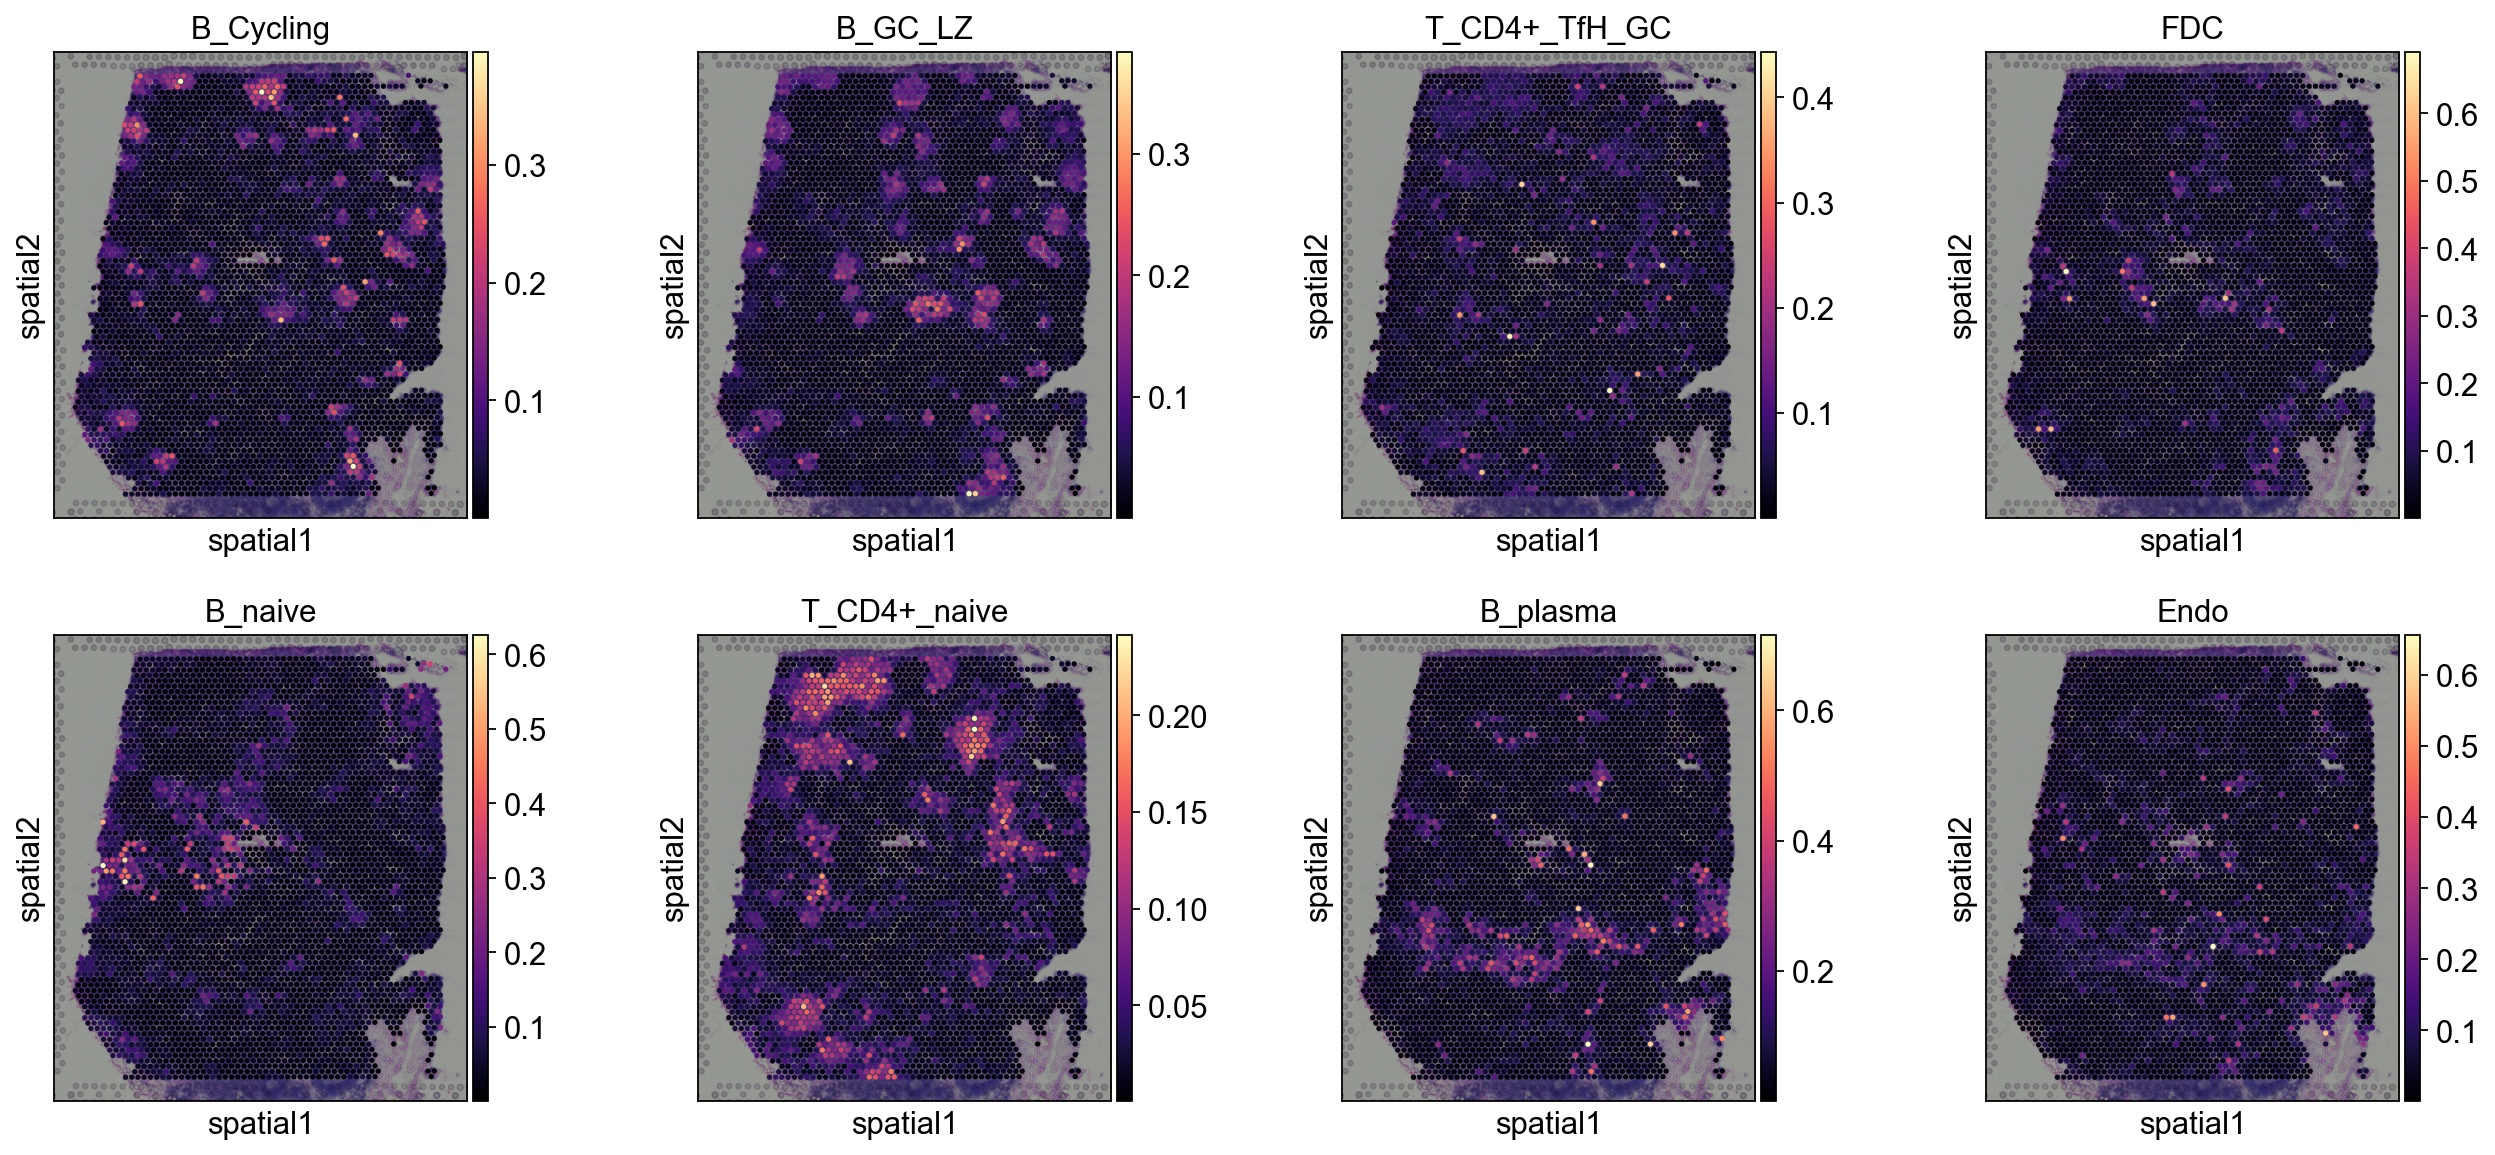

In [9]:
annotation_list=['B_Cycling', 'B_GC_LZ', 'T_CD4+_TfH_GC', 'FDC',
                'B_naive', 'T_CD4+_naive', 'B_plasma', 'Endo']
sc.pl.spatial(
    decov_obj.adata_cell2location, 
    cmap='magma',
    # show first 8 cell types
    color=annotation_list,
    ncols=4, size=1.3,
    img_key='hires',
    # limit color scale at 99.2% quantile of cell abundance
    #vmin=0, vmax='p99.2'
)

### 4.2 Multi-target overlay


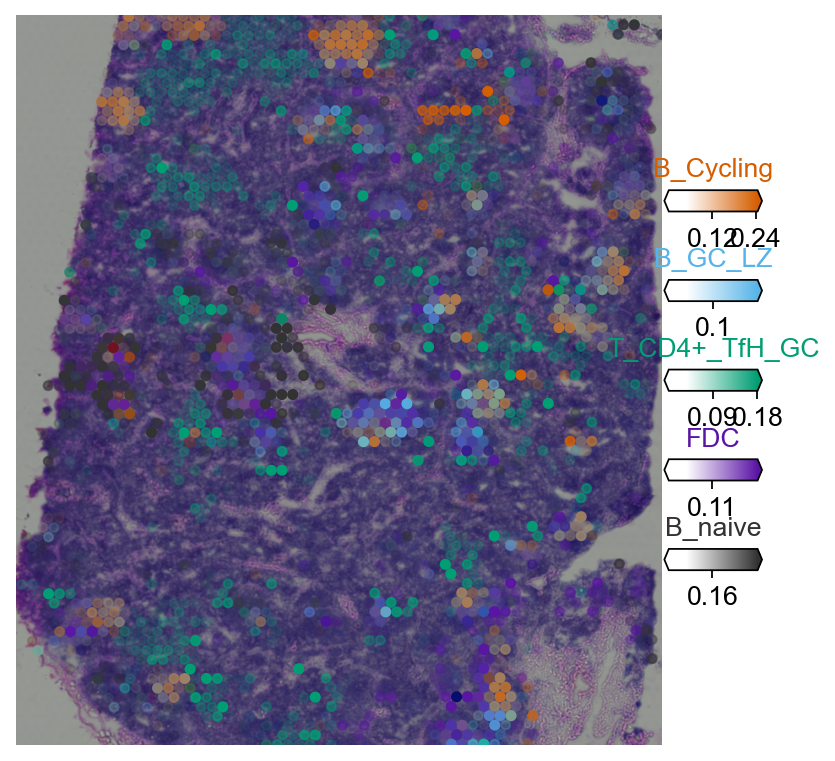

In [10]:
import matplotlib as mpl
clust_labels = annotation_list[:5]
clust_col = ['' + str(i) for i in clust_labels] # in case column names differ from labels

with mpl.rc_context({'figure.figsize': (6, 6),'axes.grid': False}):
    fig = ov.pl.plot_spatial(
        adata=decov_obj.adata_cell2location,
        # labels to show on a plot
        color=clust_col, labels=clust_labels,
        show_img=True,
        # 'fast' (white background) or 'dark_background'
        style='fast',
        # limit color scale at 99.2% quantile of cell abundance
        max_color_quantile=0.992,
        # size of locations (adjust depending on figure size)
        circle_diameter=4,
        reorder_cmap = [#0,
            1,2,3,4,6], #['yellow', 'orange', 'blue', 'green', 'purple', 'grey', 'white'],
        colorbar_position='right',
        #palette=color_dict
    )
    

### 4.3 Pie plot

We recommend cropping a region of interest before plotting to avoid overly dense pie charts on whole slides.


In [11]:
adata_s = ov.space.crop_space_visium(
    decov_obj.adata_cell2location, 
    crop_loc=(0, 0),      
    crop_area=(500, 1000), 
    library_id=list(decov_obj.adata_cell2location.uns['spatial'].keys())[0] , 
    scale=1
)

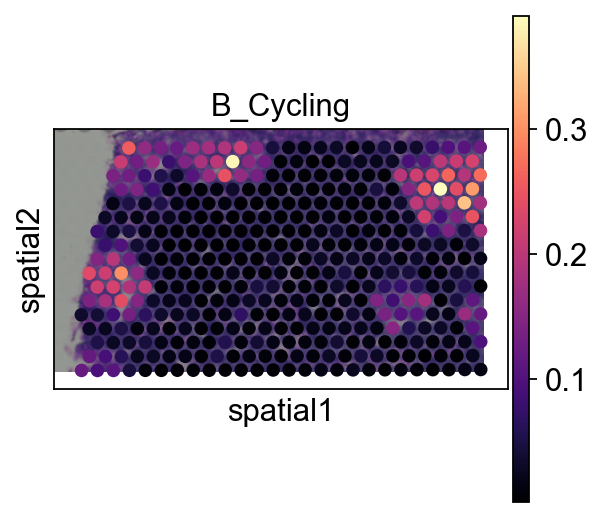

In [12]:
sc.pl.spatial(adata_s, cmap='magma',
                  # show first 8 cell types
                  color=annotation_list[0],
                  ncols=4, size=1.3,
                  img_key='hires',
                  # limit color scale at 99.2% quantile of cell abundance
                  #vmin=0, vmax='p99.2'
                 )

In [13]:
color_dict=dict(zip(annotation_list,
                   ov.pl.sc_color))

  0%|                                                                                                 | 0/417 [00:00<?, ?it/s]

  8%|███████▎                                                                               | 35/417 [00:00<00:01, 339.48it/s]

 18%|███████████████▋                                                                       | 75/417 [00:00<00:00, 373.00it/s]

 27%|███████████████████████▌                                                              | 114/417 [00:00<00:00, 375.95it/s]

 37%|███████████████████████████████▉                                                      | 155/417 [00:00<00:00, 388.12it/s]

...

 75%|████████████████████████████████████████████████████████████████▌                     | 313/417 [00:00<00:00, 381.26it/s]

 86%|█████████████████████████████████████████████████████████████████████████▋            | 357/417 [00:00<00:00, 397.80it/s]

 95%|█████████████████████████████████████████████████████████████████████████████████▉    | 397/417 [00:01<00:00, 396.82it/s]

100%|██████████████████████████████████████████████████████████████████████████████████████| 417/417 [00:01<00:00, 385.50it/s]

<Axes: xlabel='spatial1', ylabel='spatial2'>

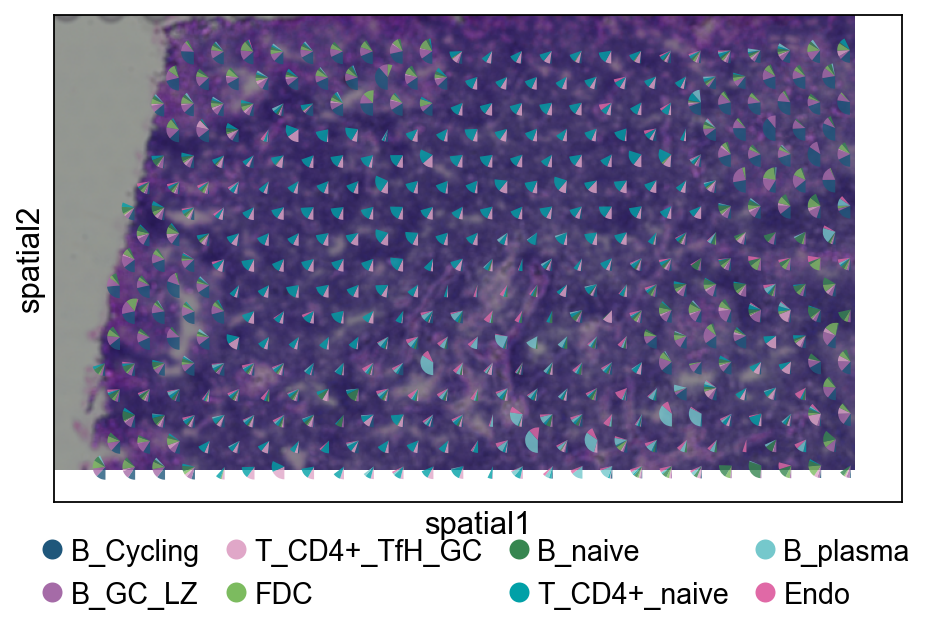

In [14]:
fig, ax = ov.plt.subplots(figsize=(8, 4))
sc.pl.spatial(
    adata_s, 
    basis='spatial',
    color=None,  
    size=1.3,
    img_key='hires',
    ax=ax,      
    show=False
)

ov.pl.add_pie2spatial(
    adata_s,
    img_key='hires',
    cell_type_columns=annotation_list[:],
    ax=ax,
    colors=color_dict,
    pie_radius=10,
    remainder='gap',
    legend_loc=(0.5, -0.25),
    ncols=4,
    alpha=0.8
)

#plt.show()